# 🔬 Root Cause Analysis — Multi-Factor Risk Scoring
**Objective:** Combine the 5 identified churn signals into a composite Risk Score (0 to 5) to quantify how risk factors compound customer cancellation rate and revenue loss.

In [4]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine

# Visual formatting
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "font.size": 10})

# Set plot directory
output_dir = "plots"
os.makedirs(output_dir, exist_ok=True)

# 1. Connect to MySQL Database using your password
DB_USER = "root"
DB_PASS = "soumo444"  # <-- Your password is set here
DB_HOST = "localhost"
DB_NAME = "customer_churn_retention"

try:
    engine = create_engine(
        f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}/{DB_NAME}"
    )
    df = pd.read_sql("SELECT * FROM customers", engine)
    print(" Successfully connected to MySQL database!")
except Exception as e:
    print(f" Could not connect to MySQL: {e}")
    print("Attempting to load local Excel file...")

    # Flexible path check for fallback
    path1 = "../01_Data_Collection/customer_churn_raw.xlsx"
    path2 = "01_Data_Collection/customer_churn_raw.xlsx"

    if os.path.exists(path1):
        df = pd.read_excel(path1)
    elif os.path.exists(path2):
        df = pd.read_excel(path2)
    else:
        raise FileNotFoundError(
            "Could not locate customer_churn_raw.xlsx in 01_Data_Collection folder."
        )

print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

 Successfully connected to MySQL database!
Dataset Loaded: 10000 rows, 32 columns


In [5]:
# Create 5 binary risk flags (1 = Risk Active, 0 = Normal)
df["new_customer_risk"] = (df["tenure_months"] <= 6).astype(int)
df["low_engagement_risk"] = (df["monthly_logins"] <= 4).astype(int)
df["payment_failure_risk"] = (df["payment_failures"] >= 2).astype(int)
df["low_satisfaction_risk"] = (df["csat_score"] <= 2).astype(int)
df["inactivity_risk"] = (df["last_login_days_ago"] >= 31).astype(int)

# Combine flags into a Composite Risk Score (0 to 5)
risk_columns = [
    "new_customer_risk",
    "low_engagement_risk",
    "payment_failure_risk",
    "low_satisfaction_risk",
    "inactivity_risk",
]

df["risk_score"] = df[risk_columns].sum(axis=1)

print("--- CUSTOMER COUNT BY RISK SCORE ---")
print(df["risk_score"].value_counts().sort_index())

--- CUSTOMER COUNT BY RISK SCORE ---
risk_score
0    6124
1    3209
2     617
3      47
4       3
Name: count, dtype: int64


In [6]:
risk_analysis = (
    df.groupby("risk_score")
    .agg(
        total_customers=("customer_id", "count"),
        churned_customers=("churn", "sum"),
        churn_rate_pct=("churn", lambda x: round(x.mean() * 100, 2)),
        total_revenue=("total_revenue", "sum"),
        lost_revenue=(
            "total_revenue",
            lambda x: round(x[df.loc[x.index, "churn"] == 1].sum(), 2),
        ),
    )
    .reset_index()
)

print("--- MULTI-FACTOR RISK SCORE SUMMARY ---")
print(risk_analysis.to_string(index=False))

--- MULTI-FACTOR RISK SCORE SUMMARY ---
 risk_score  total_customers  churned_customers  churn_rate_pct  total_revenue  lost_revenue
          0             6124                119            1.94      7083160.0      149630.0
          1             3209                639           19.91      3015100.0      563130.0
          2              617                241           39.06       455620.0      143780.0
          3               47                 20           42.55        16140.0        6000.0
          4                3                  2           66.67          160.0         100.0


C:\Users\admin\AppData\Local\Temp\ipykernel_27960\1090423068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


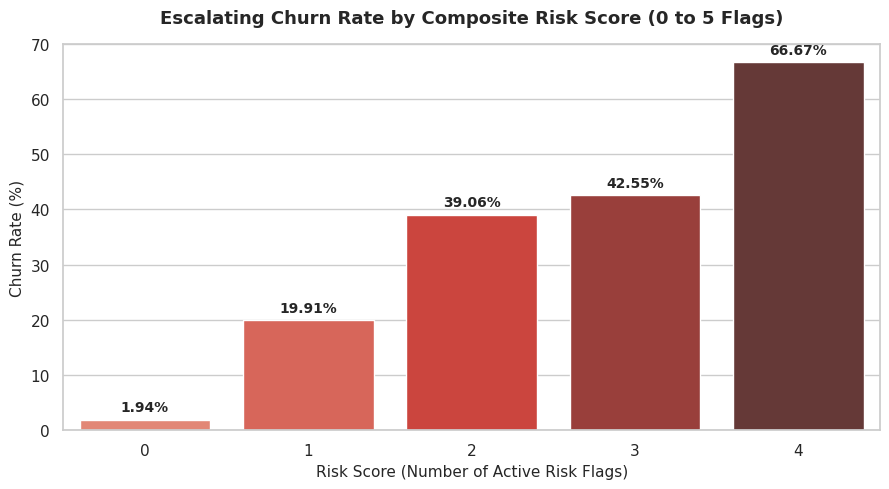

 Saved plot to: plots\05_composite_risk_score_churn.png


In [7]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=risk_analysis,
    x="risk_score",
    y="churn_rate_pct",
    palette="Reds_d",
)

plt.title(
    "Escalating Churn Rate by Composite Risk Score (0 to 5 Flags)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Risk Score (Number of Active Risk Flags)", fontsize=11)
plt.ylabel("Churn Rate (%)", fontsize=11)

# Add percentage values on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.2f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
            fontweight="bold",
        )

plt.tight_layout()
chart_path = os.path.join(output_dir, "05_composite_risk_score_churn.png")
plt.savefig(chart_path, dpi=300)
plt.show()
print(f" Saved plot to: {chart_path}")